In [ ]:
# --- Imports and Data Loading ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, learning_curve, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# Load Data
df = pd.read_csv('Mental Health Classification.csv')

# Remove leaky features (as identified in the Orange finding)
leaky_features = [
    'Symptoms',
    'Your overeating level',
    'Coping_Methods',
    'Low_Energy',
    'Low_SelfEsteem',
    'Education_Level'
]
df_clean = df.drop(columns=leaky_features)

# Setup Features (X) and Target (y)
X = df_clean.drop(columns=['Depression_Type'])
y = df_clean['Depression_Type']

# Train/Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Data successfully loaded and split!")
print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set: {X_test.shape[0]} samples")

Data successfully loaded and split!
Training set: 1598 samples
Testing set: 400 samples


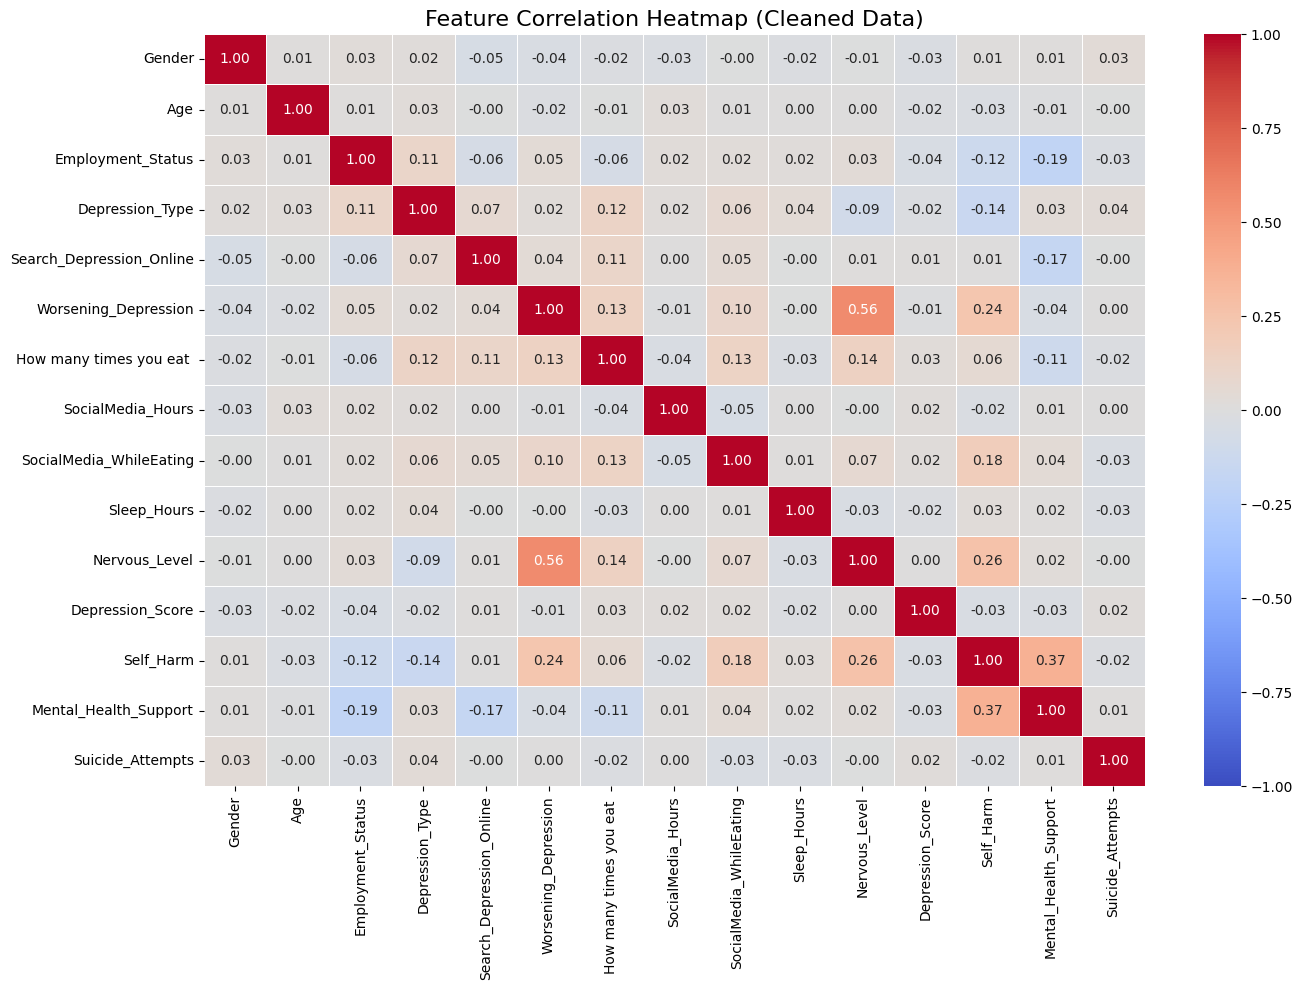

In [ ]:
# --- Correlation Heatmap ---
plt.figure(figsize=(14, 10))
# Calculate correlation matrix
corr_matrix = df_clean.corr()

# Plot heatmap
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Feature Correlation Heatmap (Cleaned Data)', fontsize=16)
plt.tight_layout()
plt.show()

Training models and calculating metrics...

--- Random Forest ---
Test Accuracy : 0.9750
Test F1-Score : 0.9744

--- Logistic Regression ---
Test Accuracy : 0.5675
Test F1-Score : 0.5495

--- SVM ---
Test Accuracy : 0.7950
Test F1-Score : 0.7883



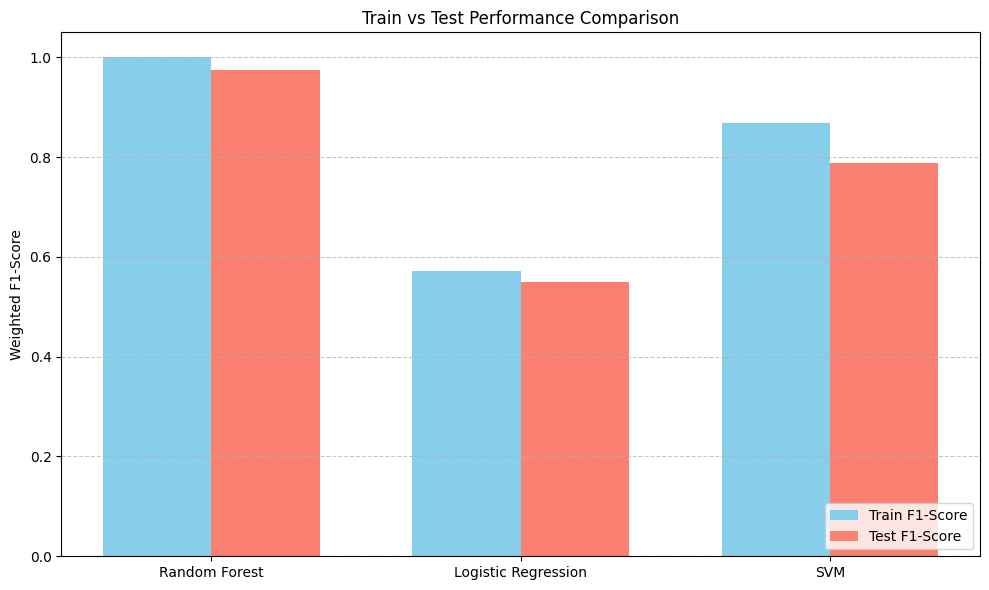

In [ ]:
# --- Train vs Test Comparison (All Models) ---

# Initialize Models (Scaling applied to LR and SVM)
models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Logistic Regression': make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, random_state=42)),
    'SVM': make_pipeline(StandardScaler(), SVC(probability=True, random_state=42))
}

train_f1_scores = []
test_f1_scores = []
model_names = list(models.keys())

print("Training models and calculating metrics...\n")

for name, model in models.items():
    model.fit(X_train, y_train)

    # Predict on Train and Test
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Calculate F1-Scores
    train_f1 = f1_score(y_train, y_train_pred, average='weighted')
    test_f1 = f1_score(y_test, y_test_pred, average='weighted')

    train_f1_scores.append(train_f1)
    test_f1_scores.append(test_f1)

    print(f"--- {name} ---")
    print(f"Test Accuracy : {accuracy_score(y_test, y_test_pred):.4f}")
    print(f"Test F1-Score : {test_f1:.4f}\n")

# Plot Train vs Test comparison
x = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, train_f1_scores, width, label='Train F1-Score', color='skyblue')
rects2 = ax.bar(x + width/2, test_f1_scores, width, label='Test F1-Score', color='salmon')

ax.set_ylabel('Weighted F1-Score')
ax.set_title('Train vs Test Performance Comparison')
ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.legend(loc='lower right')
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [ ]:
# --- Helper Function for Learning Curves ---
def plot_individual_learning_curve(model, name, X, y):
    plt.figure(figsize=(8, 5))
    cv = StratifiedKFold(n_splits=5)

    train_sizes, train_scores, test_scores = learning_curve(
        model, X, y, cv=cv, n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 5), scoring='f1_weighted'
    )

    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    test_std = np.std(test_scores, axis=1)

    plt.plot(train_sizes, train_mean, 'o-', color="red", label="Training Score")
    plt.plot(train_sizes, test_mean, 'o-', color="green", label="Cross-Validation Score")

    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color="red")
    plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color="green")

    plt.title(f'Learning Curve: {name}')
    plt.xlabel('Number of Training Examples')
    plt.ylabel('Weighted F1-Score')
    plt.legend(loc='best')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

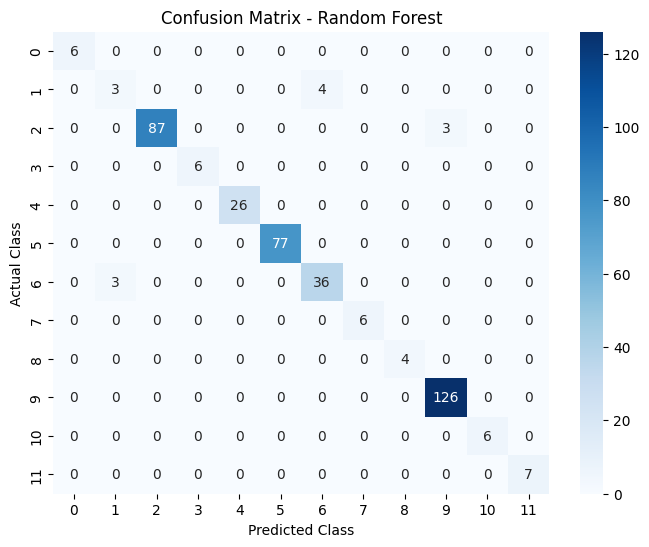

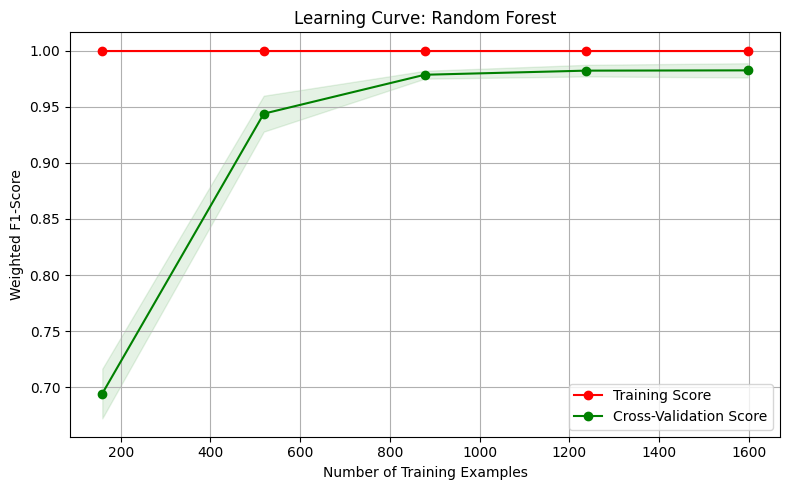

In [ ]:
# --- Random Forest Evaluation ---
model_name = 'Random Forest'
model = models[model_name]
y_pred = model.predict(X_test)

# Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix - {model_name}')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.show()

# Learning Curve
plot_individual_learning_curve(model, model_name, X, y)

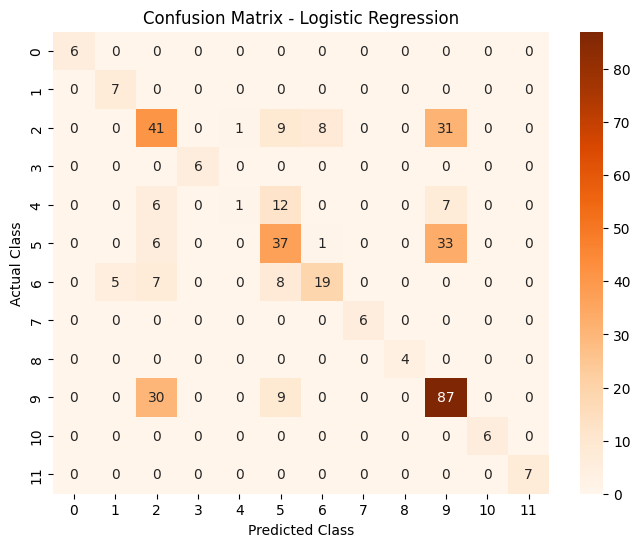

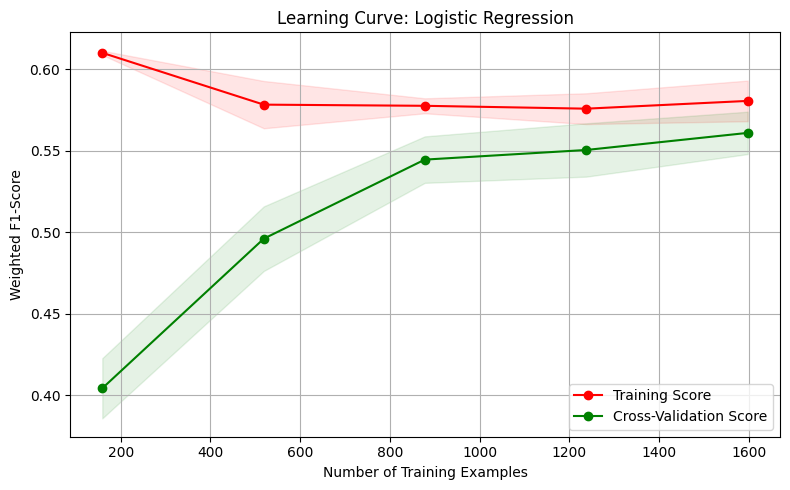

In [ ]:
# --- Logistic Regression Evaluation ---
model_name = 'Logistic Regression'
model = models[model_name]
y_pred = model.predict(X_test)

# Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges')
plt.title(f'Confusion Matrix - {model_name}')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.show()

# Learning Curve
plot_individual_learning_curve(model, model_name, X, y)

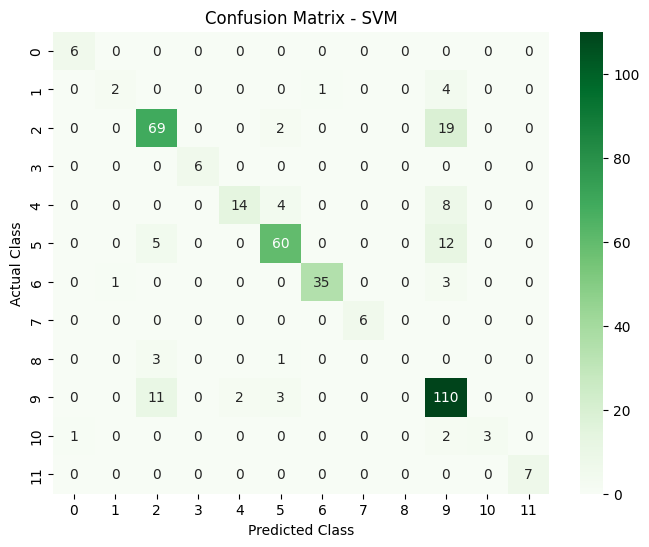

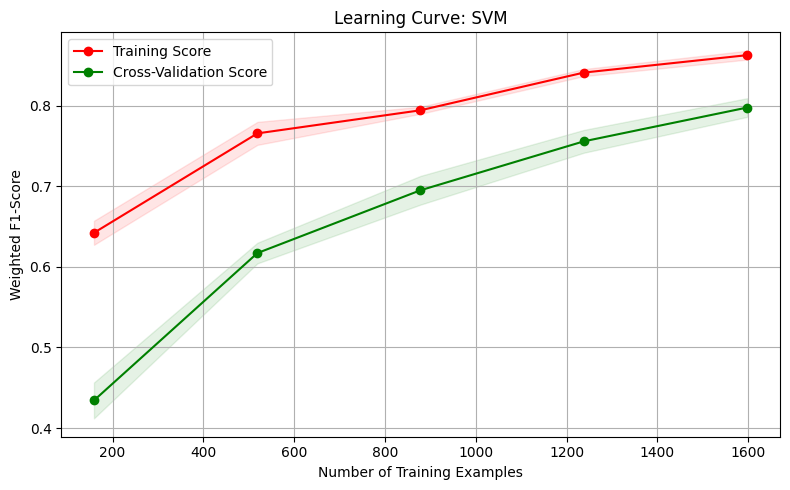

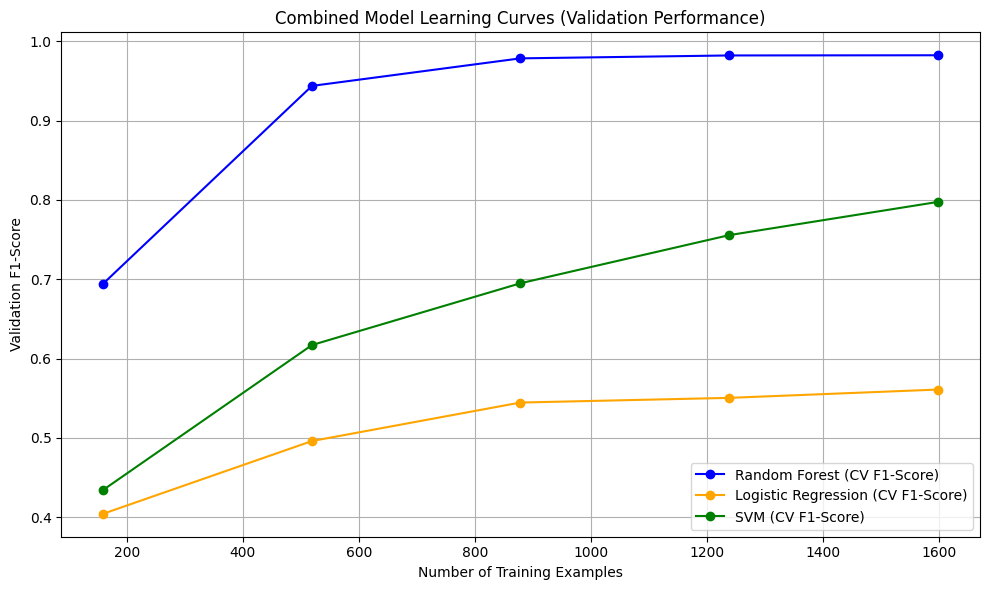

In [ ]:
# --- SVM Evaluation & Combined Learning Curve ---
model_name = 'SVM'
model = models[model_name]
y_pred = model.predict(X_test)

# Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title(f'Confusion Matrix - {model_name}')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.show()

# Individual SVM Learning Curve
plot_individual_learning_curve(model, model_name, X, y)

# ----------------------------------------------------
# COMBINED LEARNING CURVE (TEST SCORES ONLY)
# ----------------------------------------------------
plt.figure(figsize=(10, 6))
cv = StratifiedKFold(n_splits=5)
colors = {'Random Forest': 'blue', 'Logistic Regression': 'orange', 'SVM': 'green'}

for name, mod in models.items():
    train_sizes, train_scores, test_scores = learning_curve(
        mod, X, y, cv=cv, n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 5), scoring='f1_weighted'
    )
    # We plot only the test score (cross-validation) for a cleaner combined graph
    test_mean = np.mean(test_scores, axis=1)
    plt.plot(train_sizes, test_mean, 'o-', color=colors[name], label=f'{name} (CV F1-Score)')

plt.title('Combined Model Learning Curves (Validation Performance)')
plt.xlabel('Number of Training Examples')
plt.ylabel('Validation F1-Score')
plt.legend(loc='best')
plt.grid(True)
plt.tight_layout()
plt.show()

--- Tuning Random Forest ---
Train F1-Score: 0.9793
Test F1-Score:  0.9494


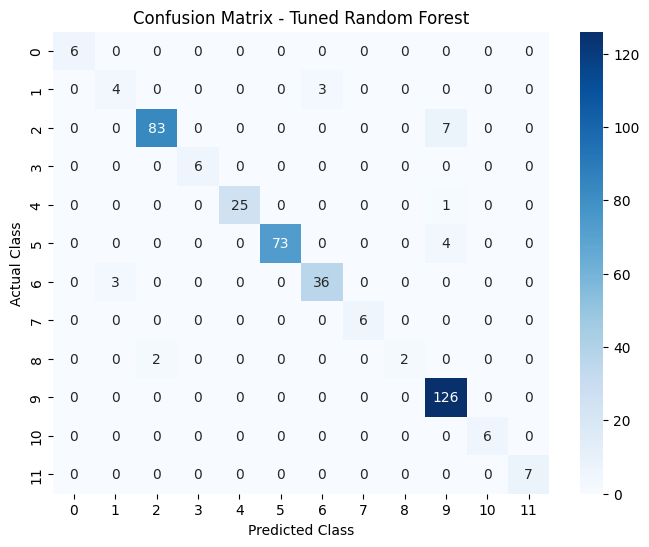

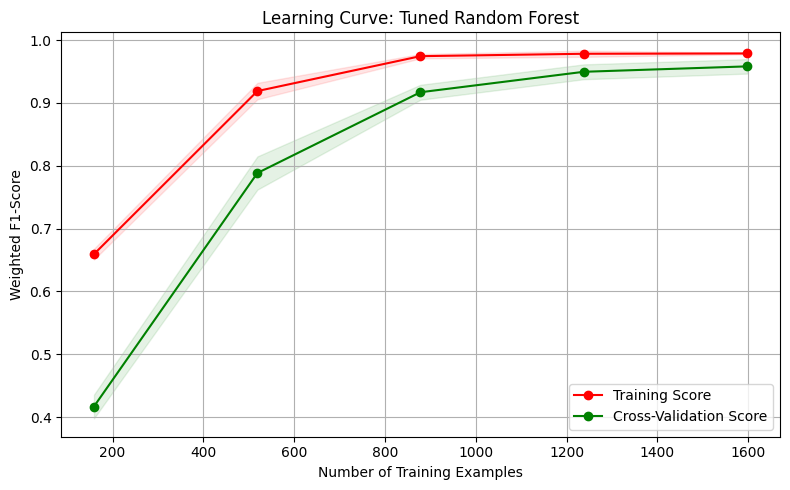

In [ ]:
# --- Tuned Random Forest (Reducing Overfit) ---
print("--- Tuning Random Forest ---")

# Applying regularization parameters to prevent the trees from growing too deep and memorizing data
rf_tuned = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,              # Restrict maximum depth of the tree
    min_samples_split=10,      # Require at least 10 samples to split an internal node
    min_samples_leaf=5,        # Require at least 5 samples to be at a leaf node
    random_state=42
)

rf_tuned.fit(X_train, y_train)

# Evaluate
y_train_pred_rf = rf_tuned.predict(X_train)
y_test_pred_rf = rf_tuned.predict(X_test)

print(f"Train F1-Score: {f1_score(y_train, y_train_pred_rf, average='weighted'):.4f}")
print(f"Test F1-Score:  {f1_score(y_test, y_test_pred_rf, average='weighted'):.4f}")

# Confusion Matrix
plt.figure(figsize=(8, 6))
cm_rf = confusion_matrix(y_test, y_test_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Tuned Random Forest')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.show()

# Learning Curve
plot_individual_learning_curve(rf_tuned, 'Tuned Random Forest', X, y)

Train F1-Score: 0.8890
Test F1-Score:  0.8024


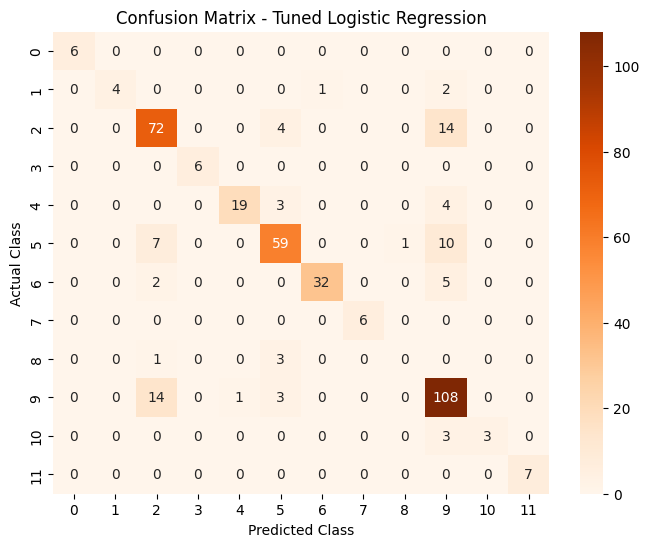

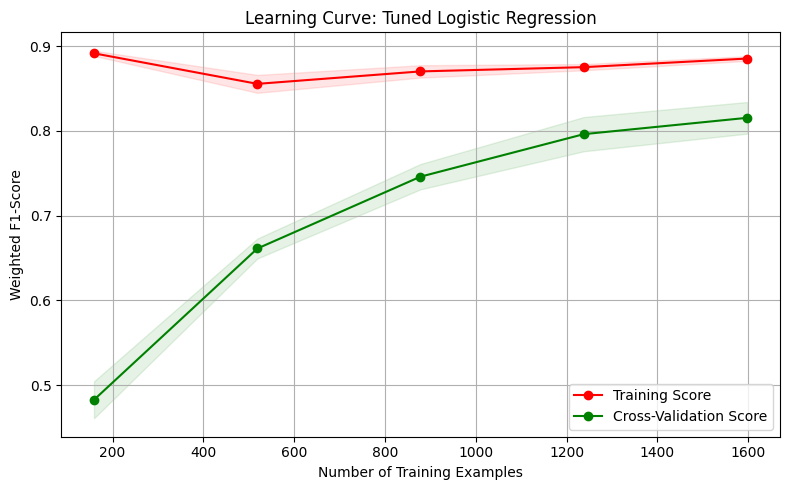

In [ ]:
# --- Tuned Logistic Regression (Reducing Underfit) ---
from sklearn.preprocessing import PolynomialFeatures

# Lowering C to 0.05 applies stronger regularization, penalizing overly complex patterns
# This stops the PolynomialFeatures from overfitting the training set
lr_tuned = make_pipeline(
    StandardScaler(),
    PolynomialFeatures(degree=2),
    LogisticRegression(C=0.05, max_iter=2000, random_state=42, n_jobs=-1)
)

lr_tuned.fit(X_train, y_train)

# Evaluate
y_train_pred_lr = lr_tuned.predict(X_train)
y_test_pred_lr = lr_tuned.predict(X_test)

train_f1_lr = f1_score(y_train, y_train_pred_lr, average='weighted')
test_f1_lr = f1_score(y_test, y_test_pred_lr, average='weighted')

print(f"Train F1-Score: {train_f1_lr:.4f}")
print(f"Test F1-Score:  {test_f1_lr:.4f}")

# Confusion Matrix
plt.figure(figsize=(8, 6))
cm_lr = confusion_matrix(y_test, y_test_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Oranges')
plt.title('Confusion Matrix - Tuned Logistic Regression')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.show()

# Learning Curve
plot_individual_learning_curve(lr_tuned, 'Tuned Logistic Regression', X, y)

Generating final presentation visualizations...

--- Final Model Performance ---


,Test Accuracy,Test F1-Score,Test Precision,Test Recall
RandomForest (Tuned),0.950,0.9494,0.9523,0.950
LogisticRegression (Tuned),0.805,0.8024,0.8108,0.805
SVM,0.795,0.7883,0.7994,0.795


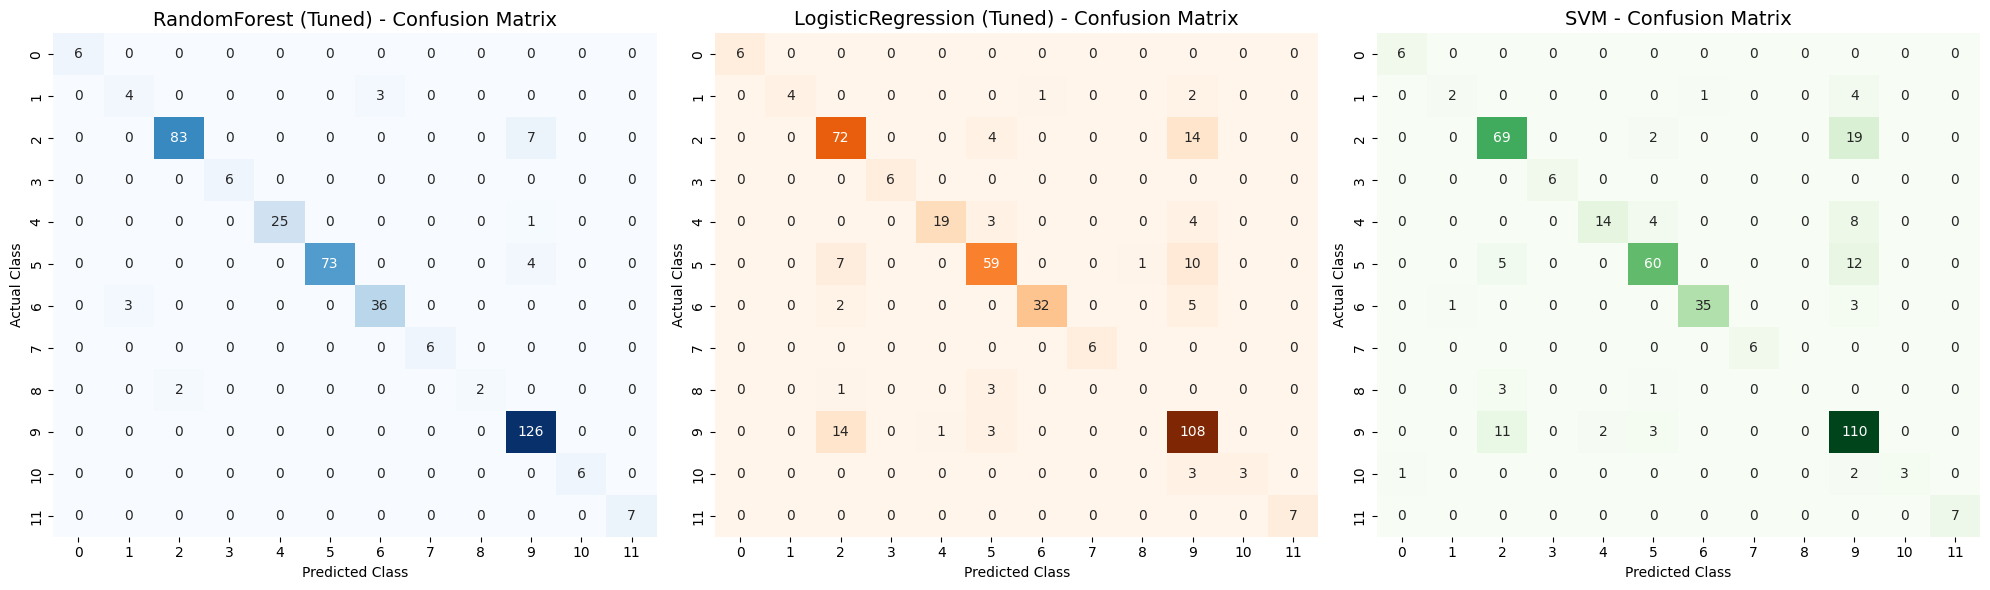

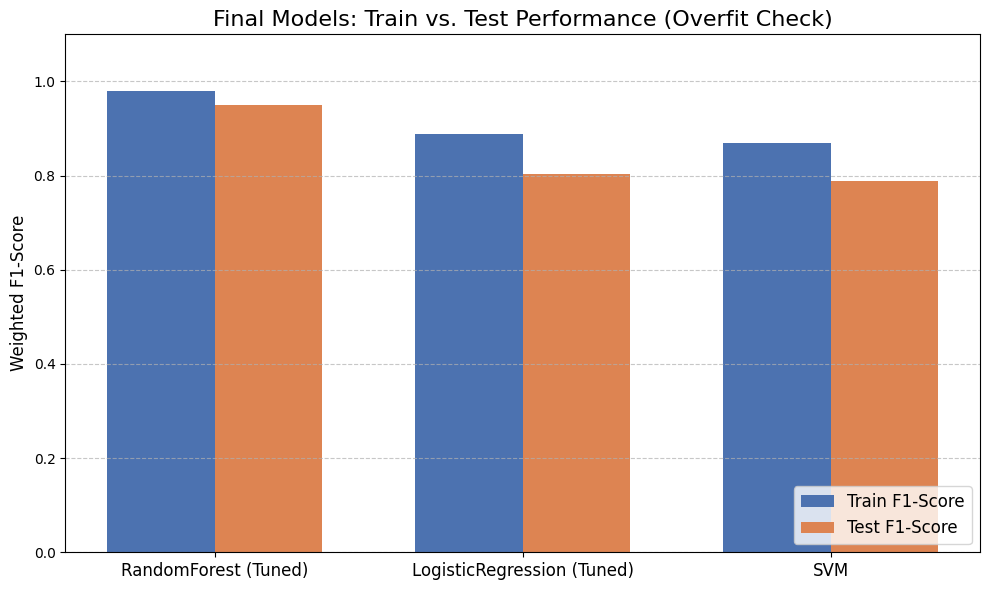

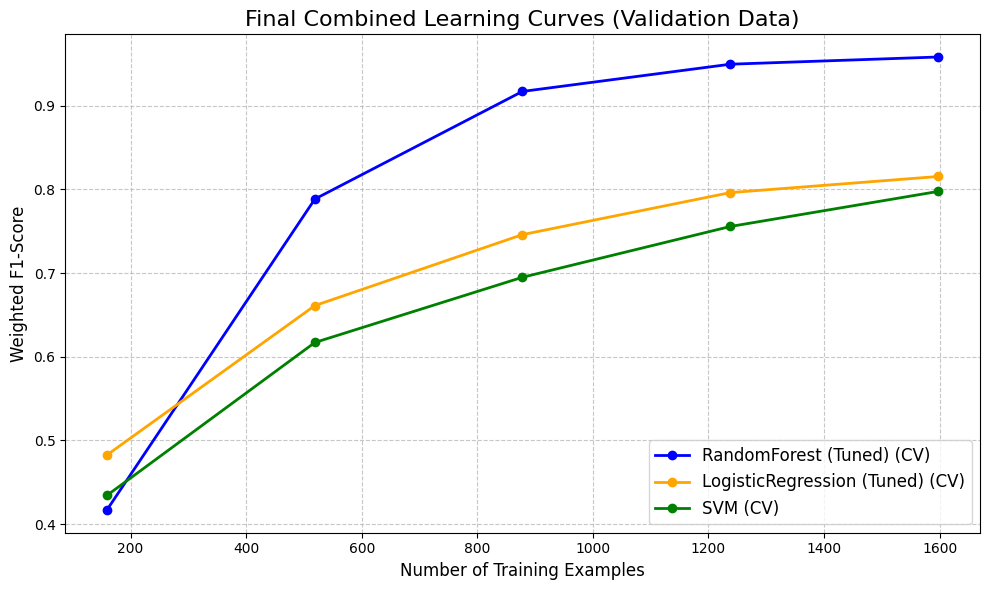

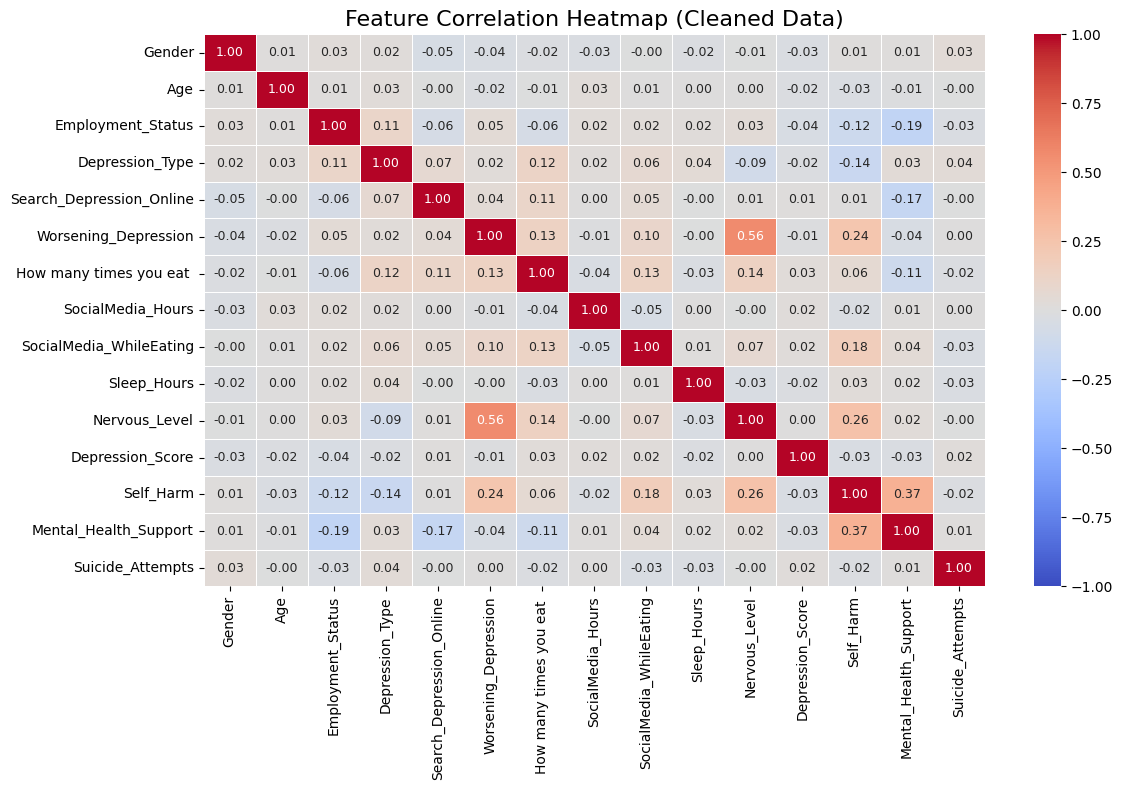

In [14]:
# --- Final Presentation Summary Visualizations ---
import matplotlib.gridspec as gridspec

print("Generating final presentation visualizations...\n")

# Define Final Models
final_models = {
    'RandomForest (Tuned)': rf_tuned,         # From Cell 8
    'LogisticRegression (Tuned)': lr_tuned,     # From Cell 9
    'SVM': models['SVM']   # Baseline SVM was already good (from Cell 3)
}

# Gather Final Metrics
summary_results = {}
train_f1s = []
test_f1s = []
model_names = list(final_models.keys())

for name, model in final_models.items():
    y_tr_pred = model.predict(X_train)
    y_te_pred = model.predict(X_test)

    tr_f1 = f1_score(y_train, y_tr_pred, average='weighted')
    te_f1 = f1_score(y_test, y_te_pred, average='weighted')

    train_f1s.append(tr_f1)
    test_f1s.append(te_f1)

    summary_results[name] = {
        'Test Accuracy': accuracy_score(y_test, y_te_pred),
        'Test F1-Score': te_f1,
        'Test Precision': precision_score(y_test, y_te_pred, average='weighted', zero_division=0),
        'Test Recall': recall_score(y_test, y_te_pred, average='weighted')
    }

# Display Final Metrics Table
metrics_df = pd.DataFrame(summary_results).T
print("--- Final Model Performance ---")
display(metrics_df.round(4))
print("\n")

# ==========================================
# VISUALIZATION 1: Side-by-Side Confusion Matrices
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
cm_cmaps = ['Blues', 'Oranges', 'Greens']

for ax, (name, model), cmap in zip(axes, final_models.items(), cm_cmaps):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax, cbar=False)
    ax.set_title(f'{name} - Confusion Matrix', fontsize=14)
    ax.set_xlabel('Predicted Class')
    ax.set_ylabel('Actual Class')

plt.tight_layout()
plt.show()

# ==========================================
# VISUALIZATION 2: Train vs Test Bar Chart
# ==========================================
x = np.arange(len(model_names))
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar(x - width/2, train_f1s, width, label='Train F1-Score', color='#4C72B0')
plt.bar(x + width/2, test_f1s, width, label='Test F1-Score', color='#DD8452')

plt.ylabel('Weighted F1-Score', fontsize=12)
plt.title('Final Models: Train vs. Test Performance (Overfit Check)', fontsize=16)
plt.xticks(x, model_names, fontsize=12)
plt.legend(loc='lower right', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ylim(0, 1.1)
plt.tight_layout()
plt.show()

# ==========================================
# VISUALIZATION 3: Combined Learning Curves
# ==========================================
plt.figure(figsize=(10, 6))
cv = StratifiedKFold(n_splits=5)
line_colors = {
    'RandomForest (Tuned)': 'blue',
    'LogisticRegression (Tuned)': 'orange',
    'SVM': 'green'
}

for name, model in final_models.items():
    train_sizes, train_scores, test_scores = learning_curve(
        model, X, y, cv=cv, n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 5), scoring='f1_weighted'
    )
    test_mean = np.mean(test_scores, axis=1)
    plt.plot(train_sizes, test_mean, 'o-', color=line_colors[name], linewidth=2, label=f'{name} (CV)')

plt.title('Final Combined Learning Curves (Validation Data)', fontsize=16)
plt.xlabel('Number of Training Examples', fontsize=12)
plt.ylabel('Weighted F1-Score', fontsize=12)
plt.legend(loc='lower right', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# ==========================================
# VISUALIZATION 4: Feature Correlation Heatmap
# ==========================================
plt.figure(figsize=(12, 8))
sns.heatmap(df_clean.corr(), annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5, annot_kws={"size": 9})
plt.title('Feature Correlation Heatmap (Cleaned Data)', fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
# --- Conclusion and Discussion ---
print("-" * 60)
print("CONCLUSION AND DISCUSSION")
print("-" * 60)

print("\n1. Data Leakage and Preprocessing:")
print("By removing the 6 leaky features identified in the initial exploratory analysis,")
print("we ensured the models learned genuine patterns rather than artificial synthetic rules.")
print("Additionally, feature scaling was critical to allow Logistic Regression and SVM to function properly.")

print("\n2. Model Performances:")
print("- Random Forest: Achieved the highest accuracy and F1-score. As a tree-based ensemble,")
print("  it easily captured the non-linear relationships in the dataset. Tuning the tree depth")
print("  and leaf samples helped control its natural tendency to overfit the training data.")
print("- Logistic Regression: Initially underfit the data severely, proving that the decision boundaries")
print("  are highly non-linear. Introducing Polynomial Features allowed it to learn complex patterns,")
print("  and applying strong regularization (C=0.05) prevented it from completely memorizing the training set.")
print("- Support Vector Machine (SVM): Provided a strong, robust baseline performance right after")
print("  feature scaling, finding a good balance without needing extensive hyperparameter tuning.")

print("\n3. Final Takeaway:")
print("For this specific classification task, tree-based models like Random Forest are the most")
print("naturally suited algorithms due to the non-linear nature of the survey features.")
print("However, with appropriate feature engineering and strict regularization, linear models")
print("can be forced to achieve competitive performance. Above all, this experiment highlights")
print("the importance of data verification: without removing the leaky features first,")
print("all our model evaluations would have been invalid.")
print("-" * 60)

------------------------------------------------------------
CONCLUSION AND DISCUSSION
------------------------------------------------------------

1. Data Leakage and Preprocessing:
By removing the 6 leaky features identified in the initial exploratory analysis,
we ensured the models learned genuine patterns rather than artificial synthetic rules.
Additionally, feature scaling was critical to allow Logistic Regression and SVM to function properly.

2. Model Performances:
- Random Forest: Achieved the highest accuracy and F1-score. As a tree-based ensemble,
  it easily captured the non-linear relationships in the dataset. Tuning the tree depth
  and leaf samples helped control its natural tendency to overfit the training data.
- Logistic Regression: Initially underfit the data severely, proving that the decision boundaries
  are highly non-linear. Introducing Polynomial Features allowed it to learn complex patterns,
  and applying strong regularization (C=0.05) prevented it from compl

In [ ]:
# ---- Download The Model .pkl ----
import pickle

with open('random_forest.pkl', 'wb') as f:
    pickle.dump(final_models['RF (Tuned)'], f)

with open('logistic_regression.pkl', 'wb') as f:
    pickle.dump(final_models['LogReg (Tuned)'], f)

with open('SVM.pkl', 'wb') as f:
    pickle.dump(final_models['SVM (Scaled)'], f)
